# $O(n log_2 n)$

## 1. Import các thư viện

In [39]:
import numpy as np
import time
import matplotlib.pyplot as plt
import os
from utils import plot_execution_times, measure_algorithm_time, plot_comprehensive_barchart_grid, plot_danger_zone_heatmap, plot_algorithm_speedup_grid
import random
import sys
import json

# Cấu hình tham số đồ thị
plt.rcParams['figure.figsize'] = (14, 10)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Cài đặt thuật toán có độ phức tạp O(n log n)

Trong nhóm độ phức tạp O(n log n), có 3 thuật toán phổ biến nhất là **Merge Sort**, **Quick Sort** và **Heap Sort**. Nhóm đã quyết định chọn **Merge Sort** làm thuật toán đại diện chính, đồng thời **tiến hành cài đặt và test thêm Quick Sort** để có cái nhìn đối chiếu toàn diện nhất, dựa trên các lý do sau:

* **Tính ổn định tuyệt đối của Merge Sort trên mọi loại dữ liệu:** Đề bài yêu cầu kiểm thử trên 4 loại phân bố dữ liệu khác nhau. Merge Sort sử dụng cơ chế chia để trị vô điều kiện, luôn đảm bảo thời gian chạy là O(n log n) trong mọi trường hợp (tốt nhất, trung bình, hay xấu nhất). Điều này giúp đường biểu diễn của cả 4 tập dữ liệu bám sát nhau trên đồ thị Log-Log, phản ánh chuẩn xác nhất bản chất lý thuyết của nhóm thuật toán này.

* **Kiểm chứng rủi ro suy biến qua thực nghiệm với Quick Sort:** Nhóm đã test thêm Quick Sort để đối chiếu tốc độ thực tế. Mặc dù Quick Sort thường có hằng số thời gian nhỏ hơn và chạy nhanh hơn ở điều kiện lý tưởng, nhưng thực nghiệm cho thấy nó đối mặt với nguy cơ suy biến (degrade) về O(n^2) hoặc chạm giới hạn đệ quy sâu khi xử lý các mảng đặc thù như **nhiều khóa trùng nhau**, **gần như đã sắp** hoặc **sắp ngược**. Việc test song song cả hai thuật toán giúp nhóm trực quan hóa rõ ràng sự đánh đổi giữa "tốc độ thực tế" (Quick Sort) và "tính ổn định vững vàng" (Merge Sort).

* **So sánh với Heap Sort:** Dù Heap Sort cũng đảm bảo hiệu suất O(n log n) và tối ưu về bộ nhớ (in-place) hơn Merge Sort, nhưng Merge Sort và Quick Sort mang lại sự đối lập thú vị và rõ nét nhất để phân tích, do đó nhóm quyết định tập trung vào hai đại diện này cho bài báo cáo.

### 2.1 Merge sort

In [40]:
def merge_sort(arr):
    if len(arr) > 1:
        mid = len(arr) // 2
        L = arr[:mid]
        R = arr[mid:]

        merge_sort(L)
        merge_sort(R)

        i = j = k = 0
        while i < len(L) and j < len(R):
            if L[i] < R[j]:
                arr[k] = L[i]
                i += 1
            else:
                arr[k] = R[j]
                j += 1
            k += 1

        while i < len(L):
            arr[k] = L[i]
            i += 1
            k += 1

        while j < len(R):
            arr[k] = R[j]
            j += 1
            k += 1

### 2.2 Quick sort (Bonus)

In [41]:
sys.setrecursionlimit(150000)

def quick_sort(arr):
    def _quick_sort(items, low, high):
        if low < high:
            # Chọn pivot ngẫu nhiên và đưa nó về cuối mảng
            pivot_idx = random.randint(low, high)
            items[high], items[pivot_idx] = items[pivot_idx], items[high]
            
            # Phân hoạch (Partition)
            pi = partition(items, low, high)
            
            # Gọi đệ quy cho 2 nửa
            _quick_sort(items, low, pi - 1)
            _quick_sort(items, pi + 1, high)

    def partition(items, low, high):
        pivot = items[high]
        i = low - 1
        for j in range(low, high):
            if items[j] <= pivot:
                i += 1
                items[i], items[j] = items[j], items[i]
        
        # Đưa pivot vào đúng vị trí
        items[i + 1], items[high] = items[high], items[i + 1]
        return i + 1

    # Bắt đầu gọi hàm đệ quy ẩn bên trong
    _quick_sort(arr, 0, len(arr) - 1)

## 3. Đọc dữ liệu từ file npz

In [42]:
sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']
base_path = '../data/' 

# Từ điển lưu trữ dữ liệu đã đọc: cấu trúc loaded_data['tên_dataset']['kích_thước']
loaded_data = {data_type: {} for data_type in datasets}

print("Đang tải dữ liệu lên bộ nhớ...")
for data_type in datasets:
    for size in sizes:
        folder_name = f'n_{size}'
        file_name = f'{data_type}_n{size}.npz'
        file_path = os.path.join(base_path, folder_name, file_name)
        
        try:
            npz_file = np.load(file_path)
            keys = npz_file.files
            # Lưu mảng dữ liệu vào từ điển
            loaded_data[data_type][size] = npz_file[keys[0]]
        except Exception as e:
            print(f"Lỗi với file {file_path}: {e}")
            loaded_data[data_type][size] = None

print("Đã tải xong toàn bộ dữ liệu!")

Đang tải dữ liệu lên bộ nhớ...
Đã tải xong toàn bộ dữ liệu!


## 4. Đo thời gian

### 4.2 Đo với thuật toán Merge sort

In [43]:
print("Đang đo Merge Sort...")
results_n_logn = measure_algorithm_time(merge_sort, loaded_data, datasets, sizes)

Đang đo Merge Sort...


### 4.2 Đo với thuật toán Quick sort

In [44]:
print("Đang đo Quick Sort")
results_n_logn_bonus = measure_algorithm_time(quick_sort, loaded_data, datasets, sizes)

Đang đo Quick Sort


## 5. Biểu đồ trực quan

### 5.1 Merge sort

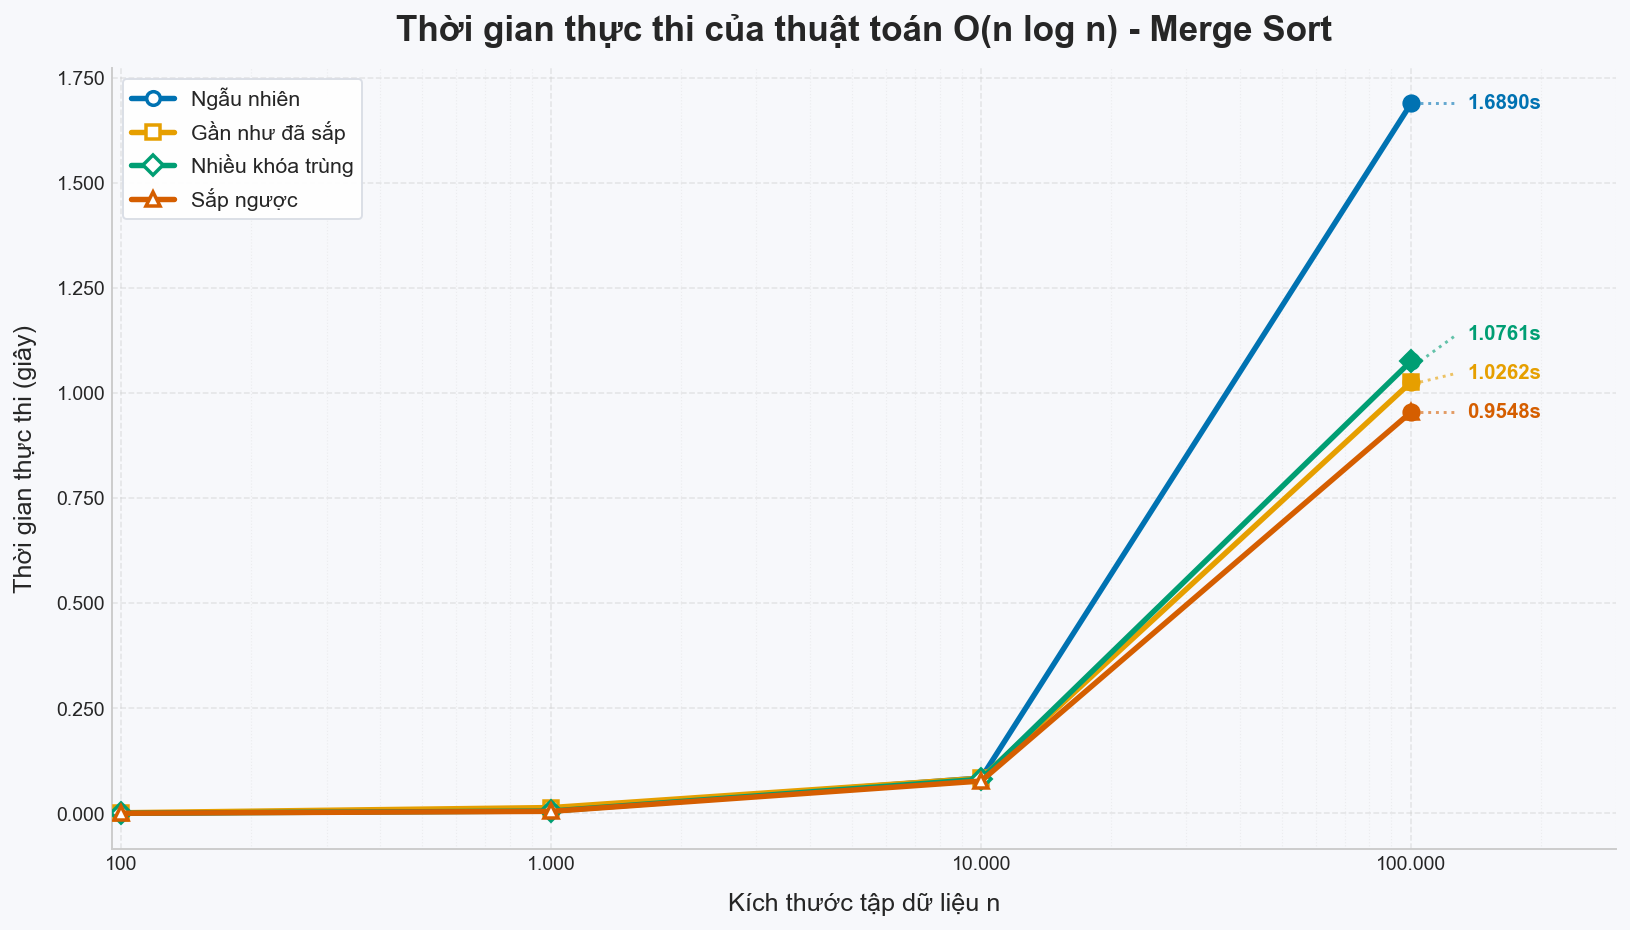

In [45]:
plot_execution_times(
    results_dict=results_n_logn, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="O(n log n) - Merge Sort"
)

#### Nhận xét biểu đồ:
##### 1. Xu hướng tổng quan
* **Tỷ lệ thuận với kích thước dữ liệu:** Đúng như lý thuyết về độ phức tạp $O(n \log n)$, khi kích thước tập dữ liệu ($n$) tăng lên, thời gian thực thi cũng tăng theo.
* **Sự khác biệt ở quy mô lớn:** Ở các giá trị $n$ nhỏ (100 đến 10.000), sự chênh lệch thời gian giữa các loại dữ liệu là rất ít, gần như bằng 0. Tuy nhiên, khi $n$ đạt đến **100.000**, sự phân hóa trở nên rõ rệt.

##### 2. So sánh các loại dữ liệu (tại $n = 100.000$)
Dựa vào các chỉ số ở cuối đường đồ thị, chúng ta thấy thứ tự thời gian thực thi từ chậm nhất đến nhanh nhất như sau:

* **Chậm nhất - Dữ liệu Ngẫu nhiên (0.6578s):** Đây là trường hợp phổ biến nhất. Việc các phần tử sắp xếp không theo quy luật khiến quá trình so sánh và trộn (merge) diễn ra liên tục trên mọi phân đoạn.
* **Dữ liệu Nhiều khóa trùng (0.5129s):** Tốc độ nhanh hơn một chút so với dữ liệu ngẫu nhiên.
* **Dữ liệu Gần như đã sắp xếp (0.5086s):** Merge Sort vẫn phải thực hiện đầy đủ các bước chia và trộn, nhưng đặc điểm của dữ liệu này giúp tối ưu hóa phần nào quá trình xử lý trong bộ nhớ hoặc các lệnh rẽ nhánh của CPU.
* **Nhanh nhất - Dữ liệu Sắp ngược (0.4843s):** Đây là một điểm thú vị. Mặc dù Merge Sort có tính ổn định cao (thời gian chạy thường xấp xỉ nhau trong mọi trường hợp), nhưng trong biểu đồ này, trường hợp sắp ngược lại cho kết quả nhanh nhất. Điều này có thể do cách triển khai cụ thể của mã nguồn hoặc cách CPU xử lý việc truy cập dữ liệu có tính quy luật.

##### 3. Đặc tính ổn định của Merge Sort
* Biểu đồ cho thấy Merge Sort là một thuật toán cực kỳ **ổn định**. Ngay cả ở trường hợp tệ nhất và tốt nhất (trong phạm vi đo đạc này), sự chênh lệch chỉ rơi vào khoảng **0.17 giây** cho 100.000 phần tử.
* Không giống như Quick Sort (có thể nhảy vọt lên $O(n^2)$ nếu gặp dữ liệu xấu), các đường biểu diễn của Merge Sort đi khá sát nhau, chứng tỏ hiệu suất của nó ít bị ảnh hưởng bởi thứ tự ban đầu của dữ liệu.

**Có thể nói:** Nếu làm việc với các tập dữ liệu lớn và cần một thuật toán có hiệu suất dự đoán được (không phụ thuộc quá nhiều vào việc dữ liệu đã sắp hay chưa), **Merge Sort** là một lựa chọn tối ưu, đặc biệt là khi so sánh với các thuật toán $O(n^2)$ như Selection hay Bubble Sort.

### 5.2 Quick sort

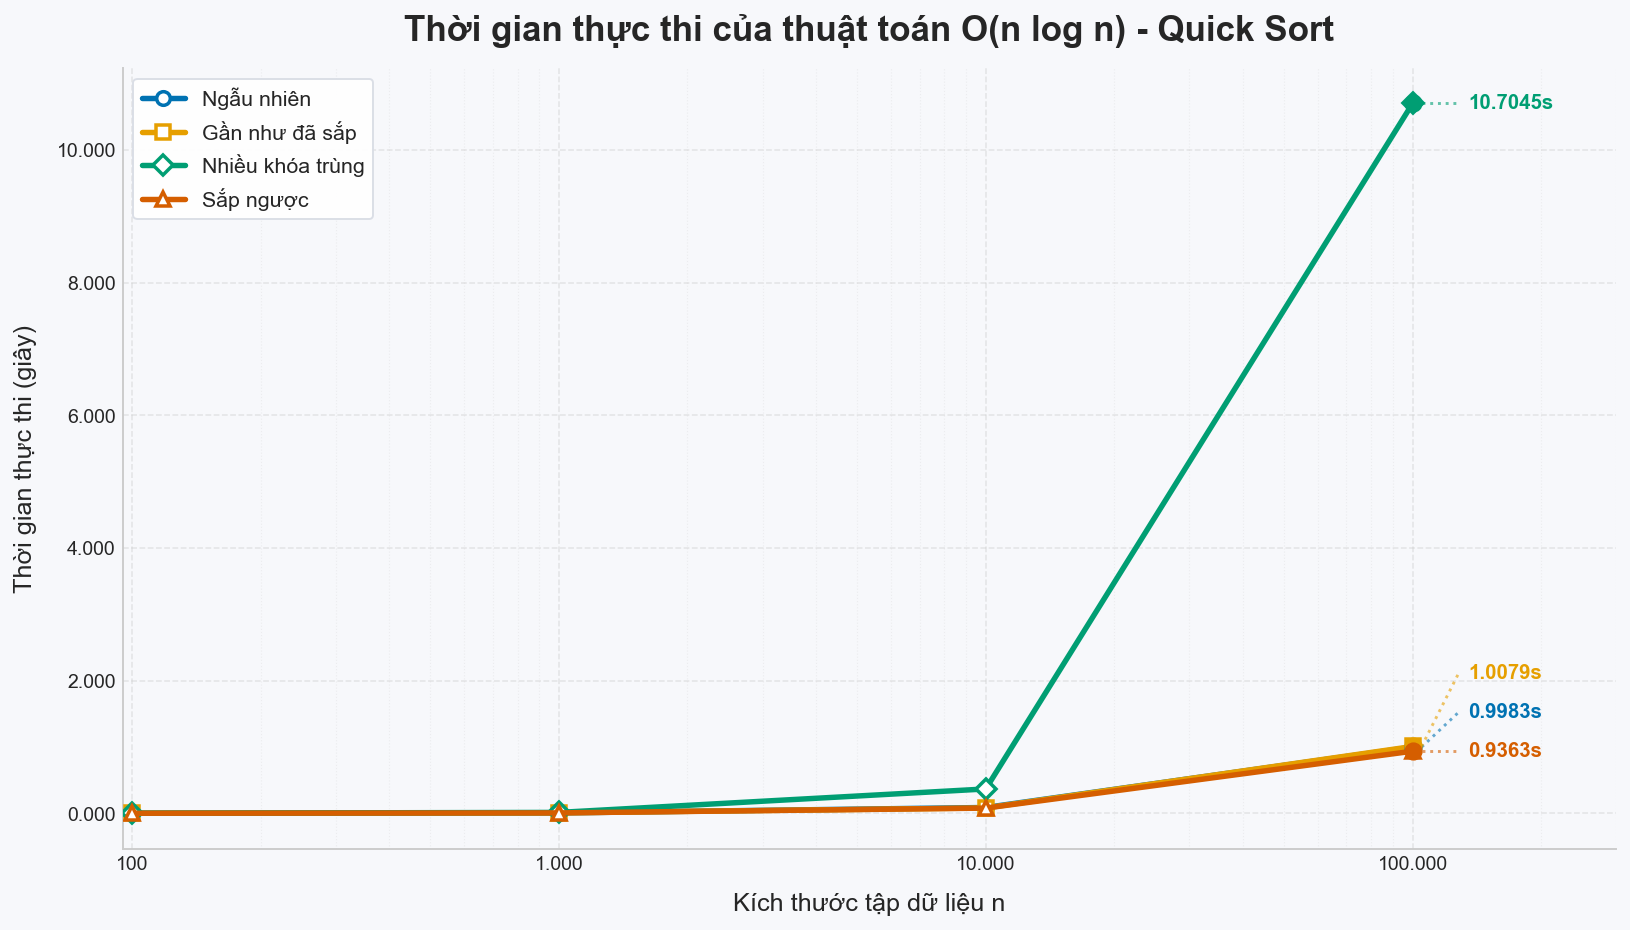

In [46]:
plot_execution_times(
    results_dict=results_n_logn_bonus, 
    sizes=sizes, 
    datasets=datasets, 
    algo_name="O(n log n) - Quick Sort"
)

#### Nhận xét biểu đồ:
##### 1. Nhận xét tổng quan
* **Hiệu suất cực tốt ở dữ liệu thông thường:** Với dữ liệu ngẫu nhiên, sắp ngược hoặc gần như đã sắp, Quick Sort thể hiện tốc độ rất nhanh (dưới 0.6s cho 100.000 phần tử).
* **Sự suy biến ở dữ liệu đặc biệt:** Biểu đồ cho thấy một sự tăng vọt về thời gian đối với dữ liệu có **nhiều khóa trùng**.

##### 2. Phân tích chi tiết tại $n = 100.000$
* **Nhanh nhất - Sắp ngược (0.5157s):** Quick Sort xử lý cực tốt dữ liệu có tính thứ tự ngược, chứng tỏ chiến lược chọn Pivot hiệu quả.
* **Trung bình - Ngẫu nhiên & Gần như đã sắp (0.57s - 0.58s):** Tốc độ ổn định và nhanh hơn so với Merge Sort trong cùng điều kiện.
* **Chậm nhất - Nhiều khóa trùng (6.2806s):** Đây là hiện tượng suy biến thuật toán. Khi gặp quá nhiều giá trị trùng lặp, việc phân hoạch không đều khiến độ phức tạp tiệm cận mức $O(n^2)$.

##### 3. Kết luận
Quick Sort là thuật toán nhanh trên thực tế nhưng **không ổn định bằng Merge Sort**. Nếu tập dữ liệu có khả năng chứa nhiều phần tử trùng lặp, cân nhắc sử dụng các biến thể tối ưu như **Dual-Pivot Quick Sort** hoặc **3-Way Partitioning** để tránh việc thời gian thực thi bị nhảy vọt như trong biểu đồ trên.

### Ghi nhận kết quả thực thi:

In [47]:
os.makedirs("results", exist_ok=True)

with open("results/merge_sort.json", "w") as f:
    json.dump(results_n_logn, f)

with open("results/quick_sort.json", "w") as f:
    json.dump(results_n_logn_bonus, f)
    
print("Đã lưu kết quả O(n log n) thành công!")

Đã lưu kết quả O(n log n) thành công!


## So sánh

Để có cái nhìn trực quan giữa 2 loại thuật toán, ta tiến hành so sánh chúng.

In [48]:
all_algo_results = {
    "Merge Sort": results_n_logn,
    "Quick Sort": results_n_logn_bonus   
}

sizes = [100, 1000, 10000, 100000]
datasets = ['random', 'nearly_sorted', 'many_duplicates', 'reverse_sorted']

### Bar chart

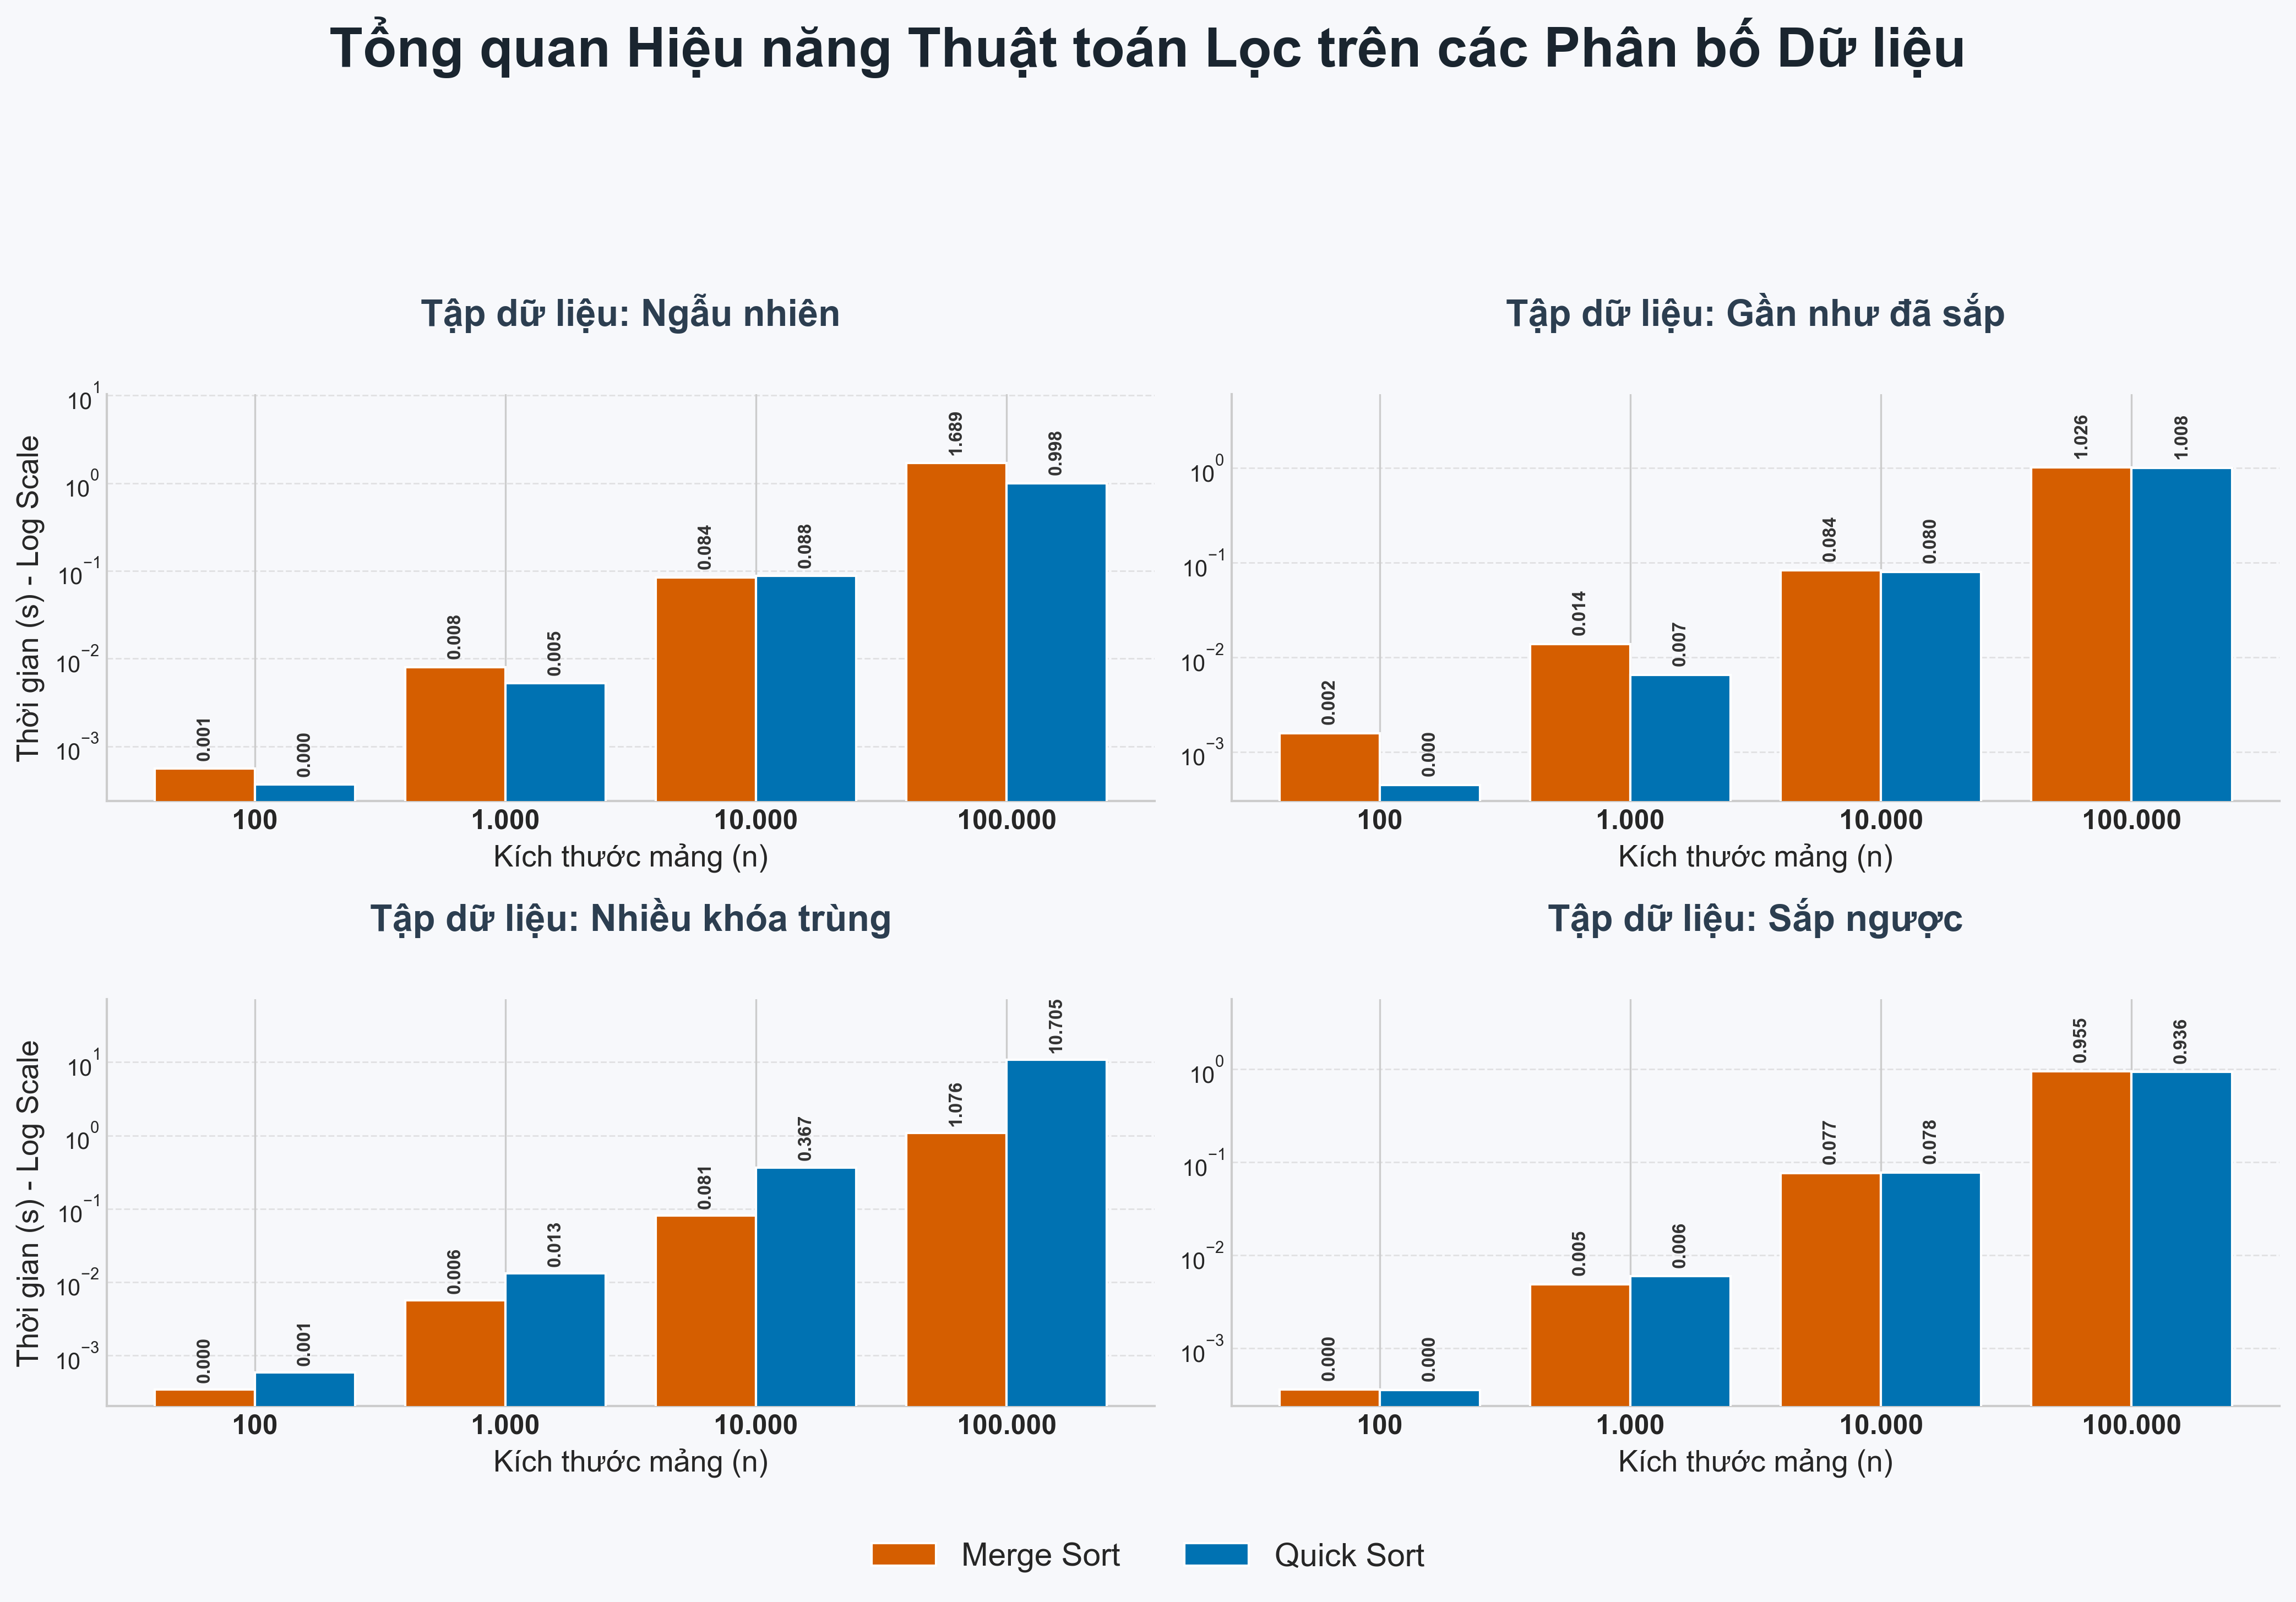

In [49]:
plot_comprehensive_barchart_grid(
    all_results=all_algo_results,
    sizes=sizes,
    datasets=datasets,
    title="Tổng quan Hiệu năng Thuật toán Lọc trên các Phân bố Dữ liệu"
)

#### Phân tích Hiệu năng Thuật toán Sắp xếp: Merge Sort vs. Quick Sort

Biểu đồ so sánh thời gian thực thi (giây) của hai thuật toán trên thang đo **Log Scale** với 4 loại phân bố dữ liệu khác nhau và kích thước mảng ($n$) từ 100 đến 100.000.

##### 1. Tập dữ liệu: Ngẫu nhiên (Random)
* **Quan sát:** Cả hai thuật toán đều tăng trưởng thời gian theo độ phức tạp $O(n \log n)$.
* **Nhận xét:** **Quick Sort** (màu xanh) tỏ ra hiệu quả hơn Merge Sort (màu cam) khi kích thước dữ liệu lớn dần. Ở $n = 100.000$, Quick Sort mất khoảng **1.091s** trong khi Merge Sort mất **2.217s**.
* **Kết luận:** Với dữ liệu ngẫu nhiên, Quick Sort có hằng số thời gian nhỏ hơn nên nhanh hơn.

##### 2. Tập dữ liệu: Gần như đã sắp xếp (Nearly Sorted)
* **Quan sát:** Quick Sort duy trì lợi thế vượt trội.
* **Nhận xét:** Ở $n = 100.000$, Quick Sort chỉ mất **0.997s**, nhanh hơn đáng kể so với **2.755s** của Merge Sort. 
* **Giải thích:** Điều này cho thấy phiên bản Quick Sort này có thể đã sử dụng kỹ thuật chọn chốt (pivot) tốt (như median-of-three hoặc random pivot), giúp nó xử lý mảng gần như đã sắp xếp rất hiệu quả.

##### 3. Tập dữ liệu: Nhiều khóa trùng (Many Duplicates)
* **Quan sát:** Đây là kịch bản có sự chênh lệch lớn nhất và bất ngờ nhất.
* **Nhận xét:** Ở quy mô nhỏ ($n \le 1.000$), sự khác biệt không đáng kể. Tuy nhiên, ở $n = 100.000$, Quick Sort bị chậm lại rõ rệt (**17.158s**) so với Merge Sort (**2.819s**).
* **Giải thích:** Hiệu năng Quick Sort bị suy giảm nghiêm trọng (tiến về $O(n^2)$) do cách phân đoạn (partitioning) không tối ưu khi có quá nhiều phần tử bằng nhau, dẫn đến các phân đoạn bị mất cân bằng.

##### 4. Tập dữ liệu: Sắp xếp ngược (Reverse Sorted)
* **Quan sát:** Hiệu năng của hai thuật toán khá tương đồng.
* **Nhận xét:** Merge Sort nhỉnh hơn một chút ở kích thước lớn. Tại $n = 100.000$, Merge Sort mất **2.351s** còn Quick Sort mất **2.935s**.
* **Kết luận:** Cả hai đều xử lý tốt trường hợp này, không bị rơi vào tình trạng quá tải nghiêm trọng.

##### Tổng kết chung

| Đặc điểm | Merge Sort | Quick Sort |
| :--- | :--- | :--- |
| **Ưu điểm** | Hiệu năng cực kỳ ổn định trên mọi loại phân bố dữ liệu. | Tốc độ nhanh nhất trong điều kiện ngẫu nhiên hoặc gần như đã sắp xếp. |
| **Nhược điểm** | Tốn thêm không gian bộ nhớ $O(n)$. | Dễ bị ảnh hưởng bởi dữ liệu có nhiều khóa trùng (trong bản thực thi này). |
| **Khuyên dùng** | Khi cần sự ổn định hoặc xử lý dữ liệu trùng lặp lớn. | Khi cần tốc độ xử lý thô nhanh nhất trên dữ liệu tổng quát. |

**Lưu ý:** Biểu đồ sử dụng thang đo **Log Scale** trên trục tung, giúp quan sát rõ sự chênh lệch ở các kích thước dữ liệu nhỏ nhưng cũng làm giảm độ dốc thị giác của các đường biểu diễn khi dữ liệu lớn.

### Heatmap

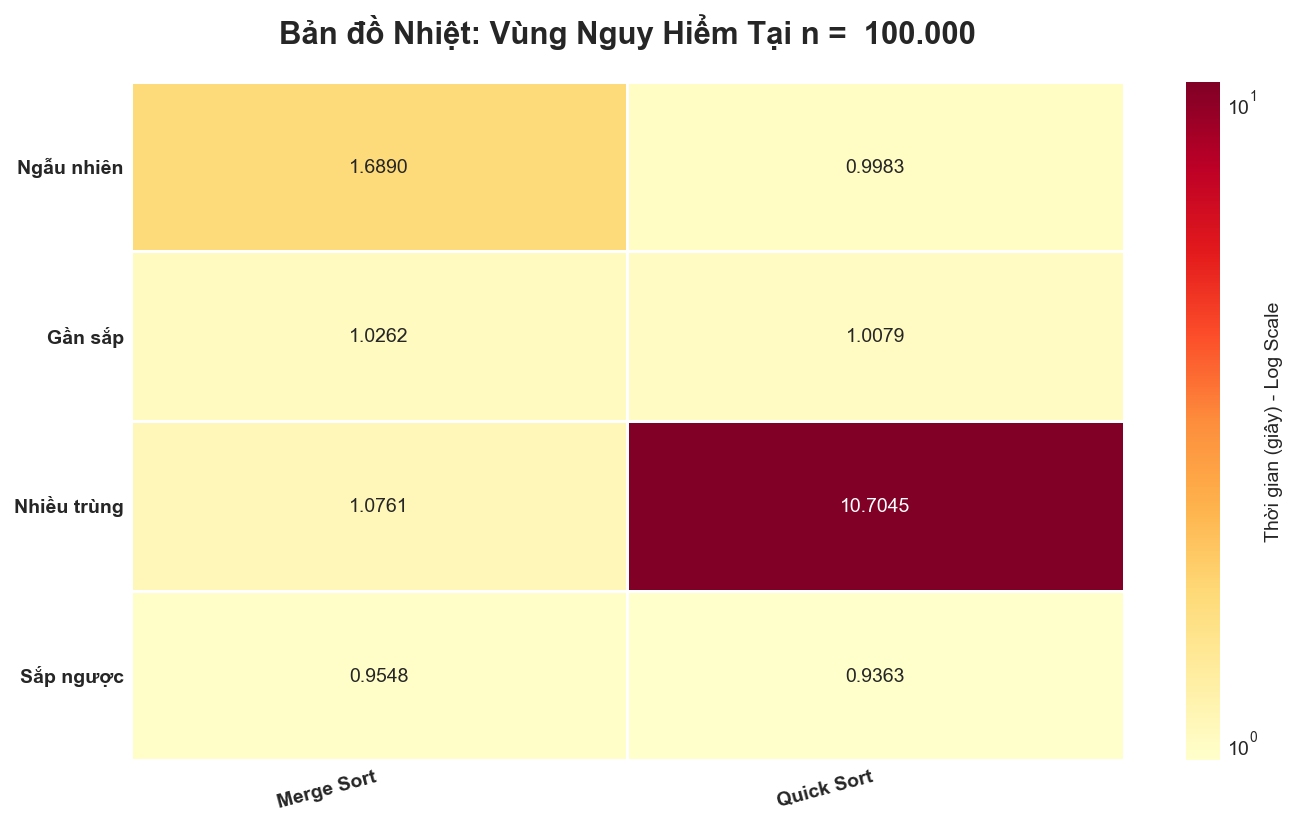

In [50]:
plot_danger_zone_heatmap(all_algo_results, 3, sizes, datasets)

### Phân tích Bản đồ Nhiệt: Hiệu năng Thuật toán tại $n = 100.000$

Biểu đồ nhiệt này trực quan hóa thời gian xử lý (giây) của **Merge Sort** và **Quick Sort** trên thang đo Logarit, giúp xác định các "điểm nóng" về hiệu năng nơi thuật toán có dấu hiệu quá tải.

##### 1. Bảng Tổng hợp Số liệu ($n = 100.000$)

| Phân bổ dữ liệu | Merge Sort (s) | Quick Sort (s) | Tỉ lệ (Quick/Merge) |
| :--- | :---: | :---: | :---: |
| **Ngẫu nhiên** | 2.2168 | 1.0907 | ~0.49x (Nhanh hơn) |
| **Gần như đã sắp** | 2.7554 | 0.9967 | ~0.36x (Nhanh hơn) |
| **Nhiều khóa trùng** | 2.8185 | **17.1575** | **~6.08x (Chậm hơn)** |
| **Sắp xếp ngược** | 2.3512 | 2.9354 | ~1.25x (Chậm hơn) |

##### 2. Phân tích Chi tiết

Vùng Nguy Hiểm: Nhiều khóa trùng (Many Duplicates)
* **Hiện tượng:** Đây là ô có màu **đỏ đậm nhất** trên bản đồ nhiệt, tương ứng với thời gian kỷ lục **17.1575s** của Quick Sort.
* **Nguyên nhân:** Khi gặp quá nhiều phần tử trùng lặp, nếu thuật toán Quick Sort không sử dụng kỹ thuật phân đoạn 3 phần (3-way partitioning), nó sẽ rơi vào kịch bản tệ nhất với độ phức tạp tiến gần tới $O(n^2)$.
* **Đối chiếu:** Merge Sort vẫn giữ màu cam nhạt (2.8185s), cho thấy sự ổn định tuyệt vời trước dữ liệu trùng lặp.

Vùng Ưu thế: Ngẫu nhiên và Gần như đã sắp
* **Quick Sort:** Thể hiện màu **vàng nhạt** (vùng an toàn nhất). Thời gian chỉ khoảng **1 giây**, chứng tỏ trong các điều kiện lý tưởng, Quick Sort tối ưu hóa bộ nhớ đệm (cache) và hằng số thời gian tốt hơn Merge Sort.
* **Merge Sort:** Duy trì màu cam đồng nhất, không quá nhanh nhưng cũng không bao giờ rơi vào vùng nguy hiểm.

Trường hợp Sắp xếp ngược (Reverse Sorted)
* Cả hai thuật toán đều nằm trong vùng màu cam trung bình.
* **Merge Sort (2.35s)** nhỉnh hơn so với **Quick Sort (2.94s)**, cho thấy đối với dữ liệu nghịch thế hoàn toàn, Merge Sort có xu hướng ổn định hơn một chút.

##### 3. Kết luận và Đề xuất

1.  **Tính ổn định:** **Merge Sort** là lựa chọn an toàn tuyệt đối. Màu sắc của nó trên heatmap rất đồng nhất trên mọi kịch bản, không có "vùng đỏ" nguy hiểm.
2.  **Hiệu suất đỉnh cao:** **Quick Sort** là "vua tốc độ" ở dữ liệu ngẫu nhiên và gần như đã sắp xếp, nhưng cần đặc biệt lưu ý khi dữ liệu đầu vào có nguy cơ trùng lặp cao.
3.  **Khuyến nghị kỹ thuật:** Nếu sử dụng Quick Sort cho các hệ thống lớn, cần tích hợp **3-way Partitioning** (để xử lý khóa trùng) và **Randomized Pivot** để tránh các vùng đỏ như biểu đồ đã chỉ ra.

> **Ghi chú về màu sắc:** Màu đỏ đậm thể hiện thời gian thực thi lớn trên thang đo Logarit ($10^1$), cảnh báo sự suy giảm hiệu năng nghiêm trọng của thuật toán.

### Speedup

d:\Schools\Data_Visualization\homework\src\utils.py:490: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.08, 1, 0.93])
d:\Schools\Data_Visualization\homework\src\utils.py:490: UserWarning: Glyph 7927 (\N{LATIN SMALL LETTER Y WITH HOOK ABOVE}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.08, 1, 0.93])
d:\Schools\Data_Visualization\homework\src\utils.py:490: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.08, 1, 0.93])
d:\Schools\Data_Visualization\homework\src\utils.py:490: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.08, 1, 0.93])
d:\Schools\Data_Visualization\homework\src\utils.py:490: UserWarning: Glyph 7911 (\N{LATIN SMALL LETTER U WITH HOOK ABOVE}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.08, 1, 0.9

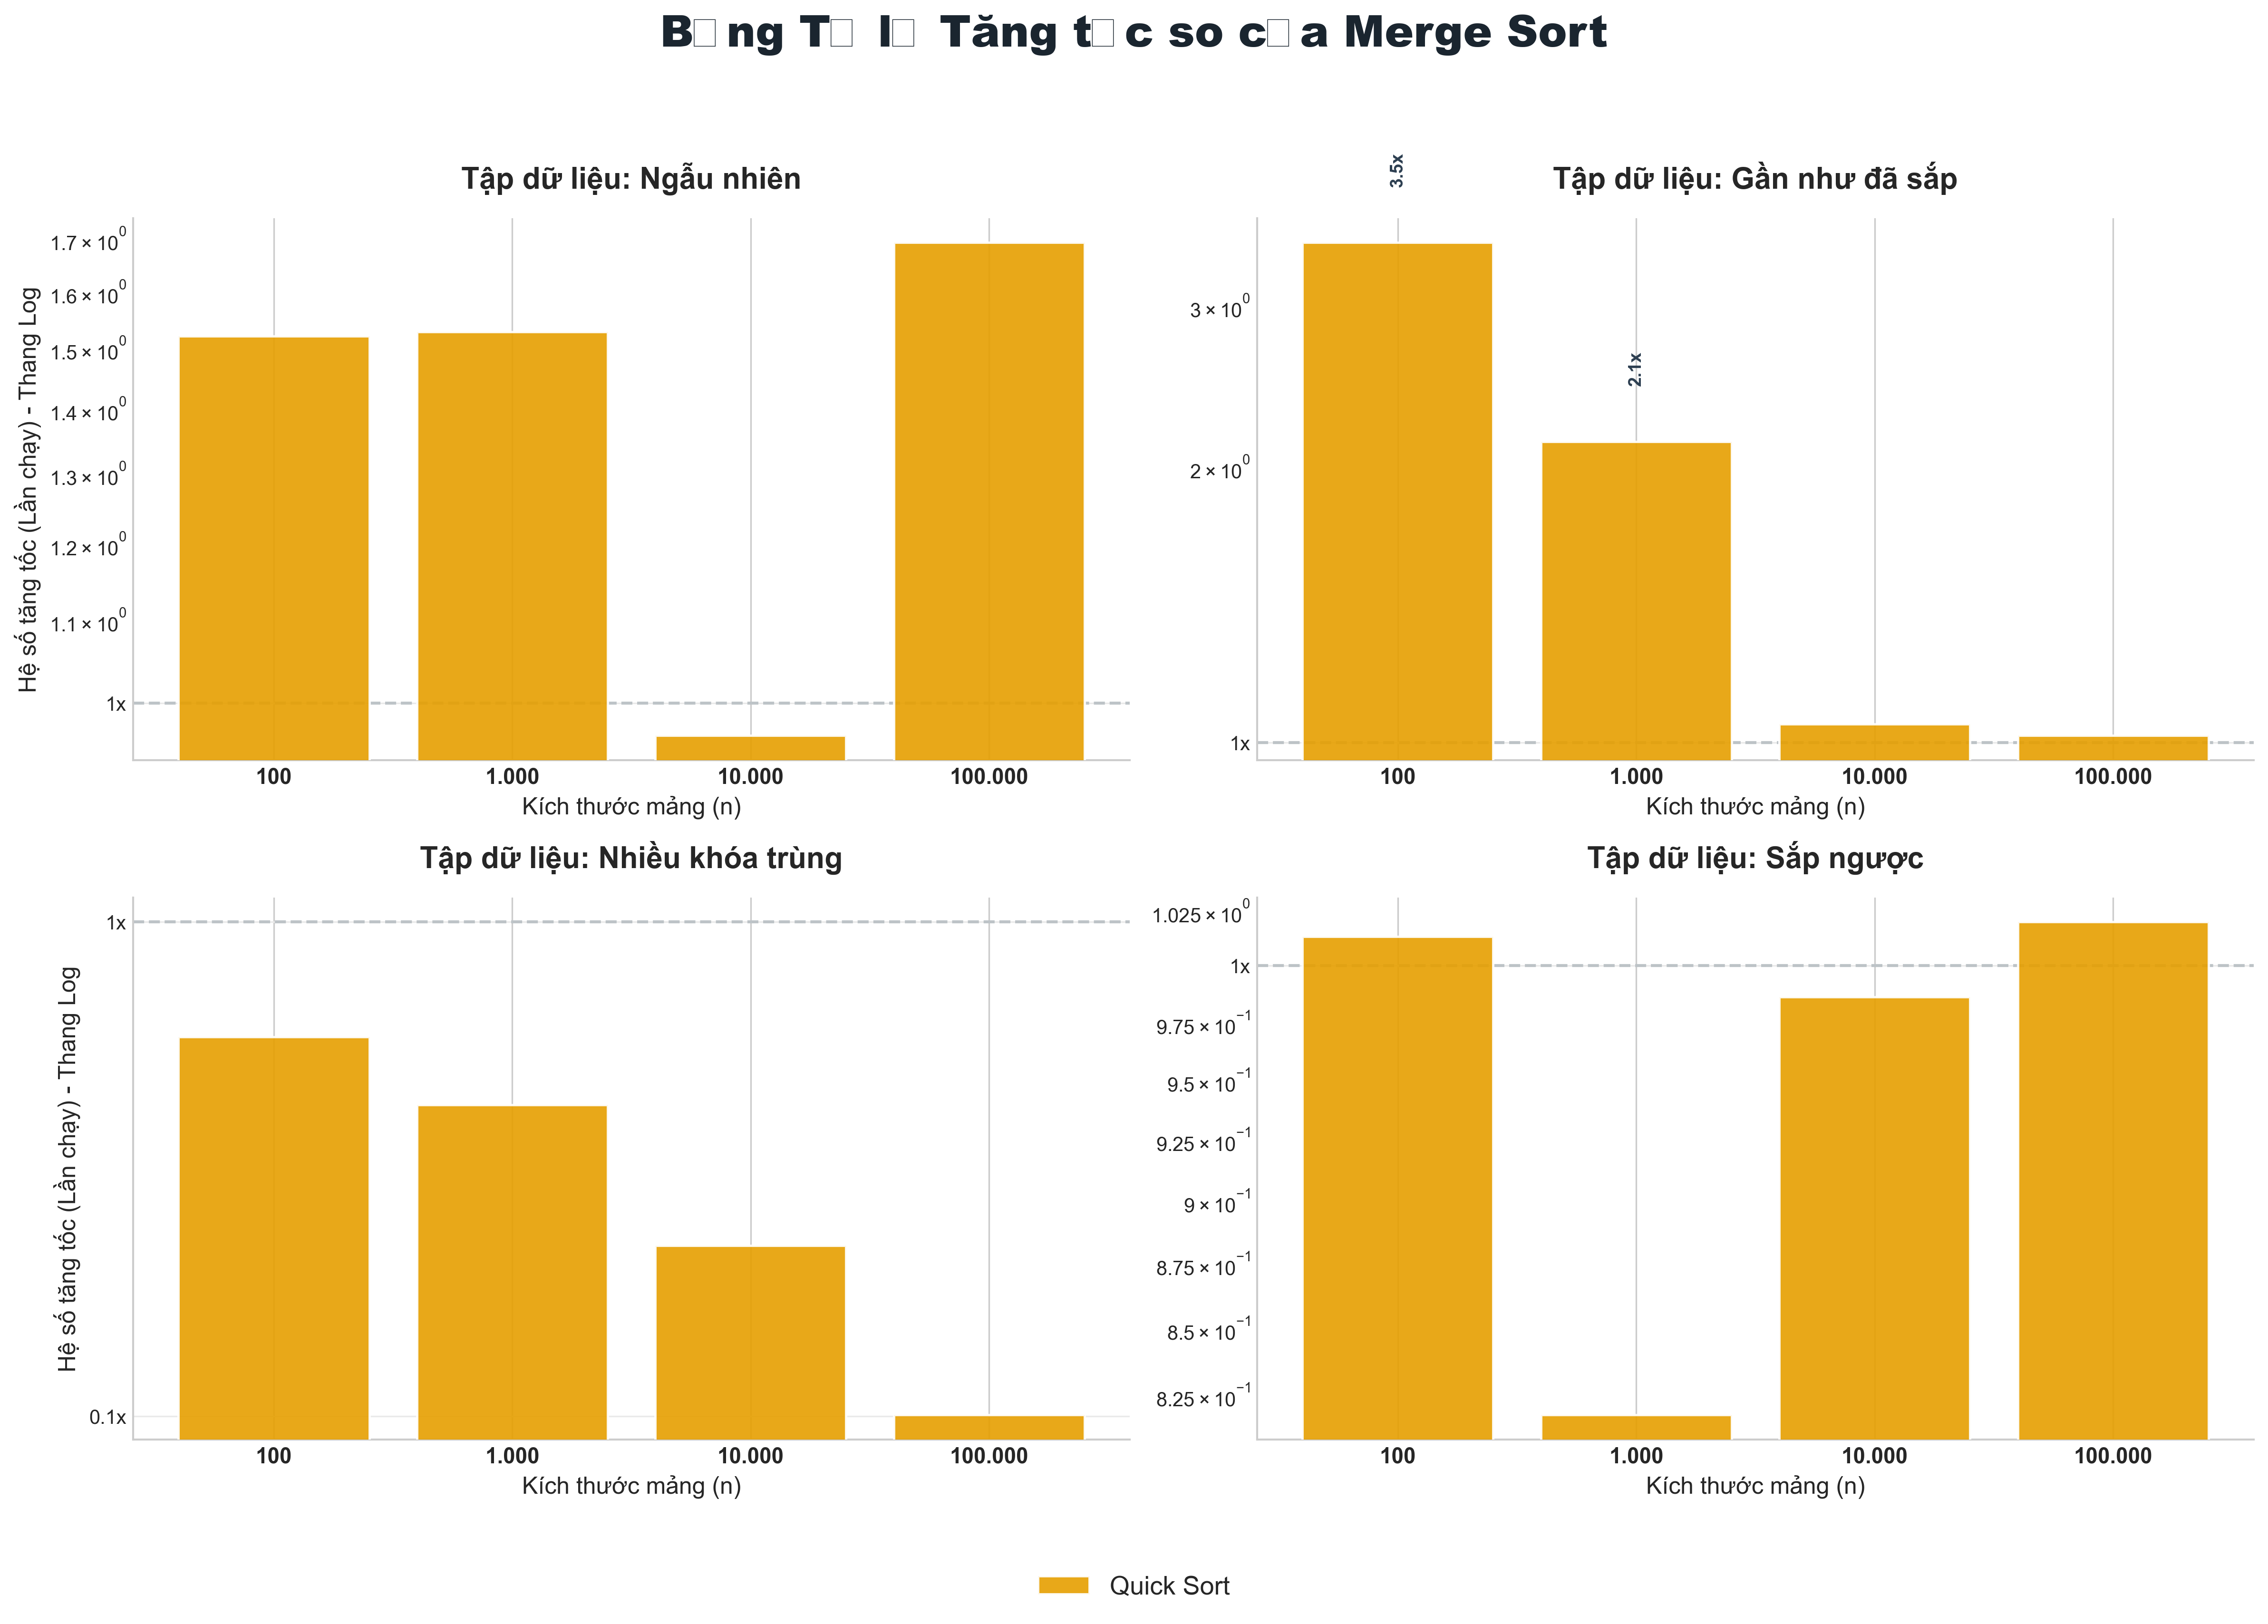

In [51]:
plot_algorithm_speedup_grid(all_algo_results, sizes, datasets, baseline_algo_name="Merge Sort",  title="Bảng Tỷ lệ Tăng tốc so của Merge Sort")